# Classification Exercises

## Exercise 0: Environment and libraries
The goal of this exercise is to set up the Python work environment with the required libraries.
Libraries used: pandas, numpy, matplotlib, scikit-learn, jupyter.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.datasets import make_classification, load_iris

%matplotlib inline

## Exercise 1: Logistic regression in Scikit-learn
The goal of this exercise is to learn to use Scikit-learn to classify data.

In [4]:
X = [[0],[0.1],[0.2], [1],[1.1],[1.2], [1.3]]
y = [0,0,0,1,1,1,0]

# Fit the logistic regression
model = LogisticRegression()
model.fit(X, y)

# Predict the class for x_pred = [[0.5]]
x_pred = [[0.5]]
prediction = model.predict(x_pred)
print(f"Prediction for {x_pred}: {prediction[0]}")

# Predict the probabilities for x_pred = [[0.5]]
probabilities = model.predict_proba(x_pred)
print(f"Probabilities for {x_pred}: {probabilities}")

# Print coefficients, intercept, and score
print(f"Coefficients: {model.coef_}")
print(f"Intercept: {model.intercept_}")
print(f"Score: {model.score(X, y)}")

Prediction for [[0.5]]: 0
Probabilities for [[0.5]]: [[0.61450206 0.38549794]]
Coefficients: [[0.81793264]]
Intercept: [-0.87524276]
Score: 0.7142857142857143


## Exercise 2: Sigmoid
The goal of this exercise is to learn to compute and plot the sigmoid function.

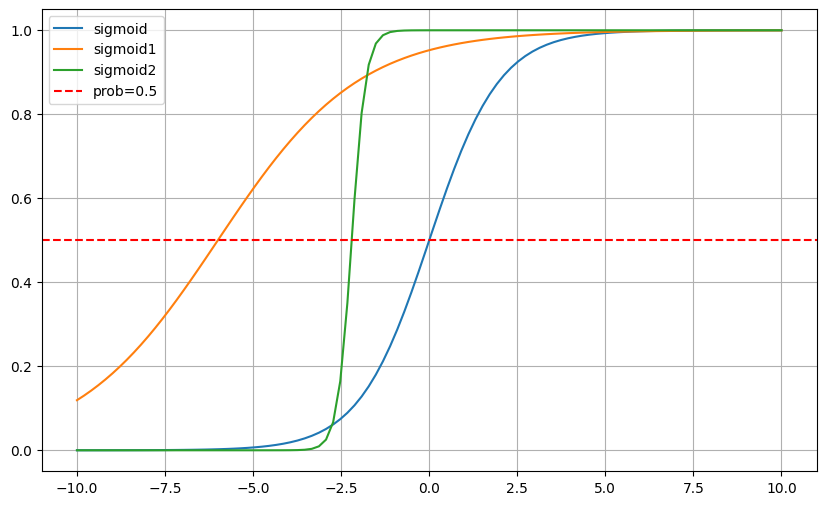

In [5]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid1(x):
    return 1 / (1 + np.exp(-(0.5*x + 3)))

def sigmoid2(x):
    return 1 / (1 + np.exp(-(5*x + 11)))

x = np.linspace(-10, 10, 100)

plt.figure(figsize=(10, 6))
plt.plot(x, sigmoid(x), label='sigmoid')
plt.plot(x, sigmoid1(x), label='sigmoid1')
plt.plot(x, sigmoid2(x), label='sigmoid2')
plt.axhline(y=0.5, color='r', linestyle='--', label='prob=0.5')
plt.legend()
plt.grid(True)
plt.show()

## Exercise 3: Decision boundary
The goal of this exercise is to learn to fit a logistic regression on simple examples and to understand how the algorithm separated the data from the different classes.

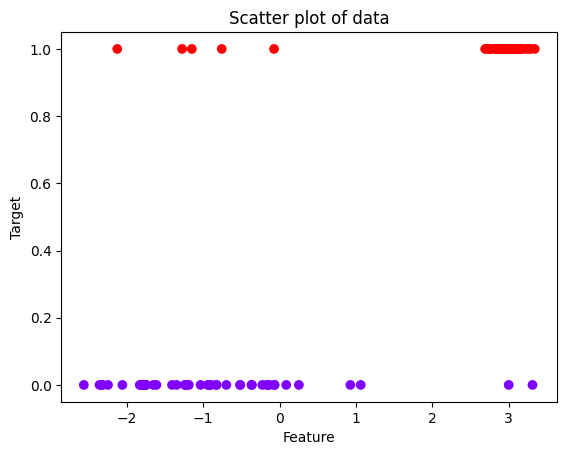

In [6]:
X, y = make_classification(
    n_samples=100,
    n_features=1,
    n_informative=1,
    n_redundant=0,
    n_repeated=0,
    n_classes=2,
    n_clusters_per_class=1,
    weights=[0.5, 0.5],
    flip_y=0.15,
    class_sep=2.0,
    hypercube=True,
    shift=1.0,
    scale=1.0,
    shuffle=True,
    random_state=88
)

plt.scatter(X, y, c=y, cmap='rainbow')
plt.title('Scatter plot of data')
plt.xlabel('Feature')
plt.ylabel('Target')
plt.show()

Coefficients: [[1.18885765]]
Intercept: [-0.98497516]


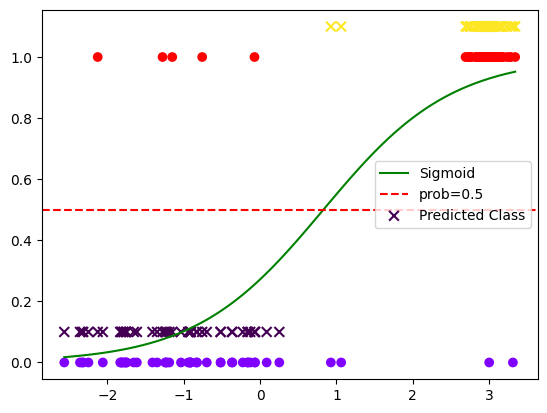

In [7]:
model = LogisticRegression()
model.fit(X, y)
print(f"Coefficients: {model.coef_}")
print(f"Intercept: {model.intercept_}")

plt.scatter(X, y, c=y, cmap='rainbow')

# Plot sigmoid
x_vals = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
probabilities = model.predict_proba(x_vals)[:, 1]
plt.plot(x_vals, probabilities, color='green', label='Sigmoid')
plt.axhline(y=0.5, color='r', linestyle='--', label='prob=0.5')

# Predict classes for plot (using scikit-learn's predict for visualization part 1)
y_pred = model.predict(X)
# Shift predicted class for visibility as requested
plt.scatter(X, y_pred + 0.1, c=y_pred, marker='x', s=50, label='Predicted Class')

plt.legend()
plt.show()

In [8]:
def predict_probability(coefs, X_val):
    # coefs = [coef, intercept]
    # p(x) = 1/(1+ exp(-(coef*x + intercept)))
    return 1 / (1 + np.exp(-(coefs[0] * X_val + coefs[1])))

coefs = [model.coef_[0][0], model.intercept_[0]]
# Check with a sample
sample_x = X[0][0]
prob_custom = predict_probability(coefs, sample_x)
prob_sklearn = model.predict_proba([[sample_x]])[0][1]
print(f"Custom Prob: {prob_custom}, Sklearn Prob: {prob_sklearn}")

Custom Prob: 0.16838474223216573, Sklearn Prob: 0.16838474223216573


In [9]:
def predict_class(coefs, X_val, threshold=0.5):
    prob = predict_probability(coefs, X_val)
    return 1 if prob >= threshold else 0

# Check with a sample
class_custom = predict_class(coefs, sample_x)
class_sklearn = model.predict([[sample_x]])[0]
print(f"Custom Class: {class_custom}, Sklearn Class: {class_sklearn}")

Custom Class: 0, Sklearn Class: 0


In [ ]:
# 2 Dimensions
X_2d, y_2d = make_classification(n_features=2,
                           n_redundant=0,
                           n_samples=250,
                           n_classes=2,
                           n_clusters_per_class=1,
                           flip_y=0.05,
                           class_sep=3,
                           random_state=43)

clf = LogisticRegression()
clf.fit(X_2d, y_2d)

xx, yy = np.mgrid[-5:5:.01, -5:5:.01]
grid = np.c_[xx.ravel(), yy.ravel()]
probs = clf.predict_proba(grid)[:, 1].reshape(xx.shape)

f, ax = plt.subplots(figsize=(8, 6))
contour = ax.contourf(xx, yy, probs, 25, cmap="RdBu",
                      vmin=0, vmax=1)
ax_c = f.colorbar(contour)
ax_c.set_label("$P(y = 1)$")
ax_c.set_ticks([0, .25, .5, .75, 1])

ax.scatter(X_2d[:,0], X_2d[:, 1], c=y_2d, s=50,
           cmap="RdBu", vmin=-.2, vmax=1.2,
           edgecolor="white", linewidth=1)

ax.set(aspect="equal",
       xlim=(-5, 5), ylim=(-5, 5),
       xlabel="$X_1$", ylabel="$X_2$")
plt.show()

## Exercise 4: Train test split
The goal of this exercise is to learn to split a classification data set.

In [10]:
X = np.arange(1,21).reshape(10,-1)
y = np.zeros(10)
y[7:] = 1

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
print(f"X_train: {X_train}")
print(f"y_train: {y_train}")
print(f"X_test: {X_test}")
print(f"y_test: {y_test}")
print(f"Train class 1 prop: {np.mean(y_train)}")
print(f"Test class 1 prop: {np.mean(y_test)}")

# Stratified split
X = np.arange(1,201).reshape(100,-1)
y = np.zeros(100)
y[70:] = 1

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=43)
print(f"Stratified Train class 1 prop: {np.mean(y_train)}")
print(f"Stratified Test class 1 prop: {np.mean(y_test)}")

X_train: [[ 1  2]
 [ 3  4]
 [ 5  6]
 [ 7  8]
 [ 9 10]
 [11 12]
 [13 14]
 [15 16]]
y_train: [0. 0. 0. 0. 0. 0. 0. 1.]
X_test: [[17 18]
 [19 20]]
y_test: [1. 1.]
Train class 1 prop: 0.125
Test class 1 prop: 1.0
Stratified Train class 1 prop: 0.3
Stratified Test class 1 prop: 0.3


## Exercise 5: Breast Cancer prediction
The goal of this exercise is to use Logistic Regression to predict breast cancer.

In [11]:
columns = ['Sample code number', 'Clump Thickness', 'Uniformity of Cell Size', 'Uniformity of Cell Shape',
           'Marginal Adhesion', 'Single Epithelial Cell Size', 'Bare Nuclei', 'Bland Chromatin',
           'Normal Nucleoli', 'Mitoses', 'Class']
df = pd.read_csv('breast-cancer-wisconsin.data', names=columns, na_values='?')

# Handle missing values
df = df.fillna(df.median())

# Drop Sample code number
df = df.drop('Sample code number', axis=1)

# Proportion of Benign (Class 2)
prop_benign = (df['Class'] == 2).mean()
print(f"Proportion of Benign: {prop_benign}")

X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=43)

clf = LogisticRegression()
clf.fit(X_train, y_train)

train_score = clf.score(X_train, y_train)
test_score = clf.score(X_test, y_test)
print(f"Train Score: {train_score}")
print(f"Test Score: {test_score}")

y_pred_train = clf.predict(X_train)
y_pred_test = clf.predict(X_test)

print("Confusion Matrix Train:")
print(confusion_matrix(y_train, y_pred_train))
print("Confusion Matrix Test:")
print(confusion_matrix(y_test, y_pred_test))

Proportion of Benign: 0.6552217453505007
Train Score: 0.9695885509838998
Test Score: 0.9642857142857143
Confusion Matrix Train:
[[357   9]
 [  8 185]]
Confusion Matrix Test:
[[90  2]
 [ 3 45]]


## Exercise 6: Multi-class (Optional)
The goal of this exercise is to learn to train a classification algorithm on a multi-class labelled data.

In [12]:
from sklearn.datasets import load_iris
iris = load_iris()
X = pd.DataFrame(data=iris['data'], columns=iris.feature_names)
y = pd.Series(data=iris['target'], name='target')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=43)

def train(X_train, y_train):
    clf0 = LogisticRegression(solver='liblinear')
    y0 = (y_train == 0).astype(int)
    clf0.fit(X_train, y0)

    clf1 = LogisticRegression(solver='liblinear')
    y1 = (y_train == 1).astype(int)
    clf1.fit(X_train, y1)

    clf2 = LogisticRegression(solver='liblinear')
    y2 = (y_train == 2).astype(int)
    clf2.fit(X_train, y2)

    return clf0, clf1, clf2

clf0, clf1, clf2 = train(X_train, y_train)

def predict_one_vs_all(X, clf0, clf1, clf2):
    prob0 = clf0.predict_proba(X)[:, 1]
    prob1 = clf1.predict_proba(X)[:, 1]
    prob2 = clf2.predict_proba(X)[:, 1]
    return np.argmax(np.column_stack([prob0, prob1, prob2]), axis=1)

y_pred = predict_one_vs_all(X_test, clf0, clf1, clf2)
print(f"Custom Accuracy: {accuracy_score(y_test, y_pred)}")

print(f"Predicted classes: {y_pred}")
clf_multi = LogisticRegression(multi_class='ovr', solver='liblinear')
clf_multi.fit(X_train, y_train)
print(f"Sklearn Accuracy: {clf_multi.score(X_test, y_test)}")

Custom Accuracy: 1.0
Sklearn Accuracy: 1.0


/Users/amir/Downloads/classification/ex00/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
